# Classification Track — Review 1 (Part A)
**Dataset:** Airline Passenger Satisfaction  
**Target:** `satisfaction` (satisfied / neutral or dissatisfied)  
**Algorithms (Part A):** Logistic Regression, K-Nearest Neighbors, Gaussian Naive Bayes, Decision Tree, Support Vector Machine

This notebook covers: dataset audit, EDA, cleaning, feature engineering, encoding/scaling/splitting,
and training + evaluating the five Part-A classification algorithms with a comparison table.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              confusion_matrix, ConfusionMatrixDisplay, roc_auc_score, roc_curve)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
sns.set_palette("colorblind")
plt.rcParams['figure.figsize'] = (8, 5)


## Section A — Dataset Audit & EDA

In [2]:
df = pd.read_csv("airlinepassenger.csv")
df = df.drop(columns=[c for c in ["Unnamed: 0", "id"] if c in df.columns])

print("Shape:", df.shape)
print("\nDtypes:\n", df.dtypes)
print("\nMissing values:\n", df.isna().sum()[df.isna().sum() > 0])
print("\nTarget distribution:\n", df['satisfaction'].value_counts())
print("\nTarget distribution (%):\n", df['satisfaction'].value_counts(normalize=True) * 100)


Shape: (25976, 23)

Dtypes:
 Gender                                   str
Customer Type                            str
Age                                    int64
Type of Travel                           str
Class                                    str
Flight Distance                        int64
Inflight wifi service                  int64
Departure/Arrival time convenient      int64
Ease of Online booking                 int64
Gate location                          int64
Food and drink                         int64
Online boarding                        int64
Seat comfort                           int64
Inflight entertainment                 int64
On-board service                       int64
Leg room service                       int64
Baggage handling                       int64
Checkin service                        int64
Inflight service                       int64
Cleanliness                            int64
Departure Delay in Minutes             int64
Arrival Delay in Minutes  

**Observation:** The dataset has 25,976 rows and 23 usable columns after dropping the two
identifier columns (`Unnamed: 0`, `id`), which carry no predictive signal and would only add noise
if left in. The only missing values are in `Arrival Delay in Minutes` (83 rows, ~0.3%). The target
classes are reasonably balanced (~55% neutral/dissatisfied vs ~45% satisfied), so no resampling is required.

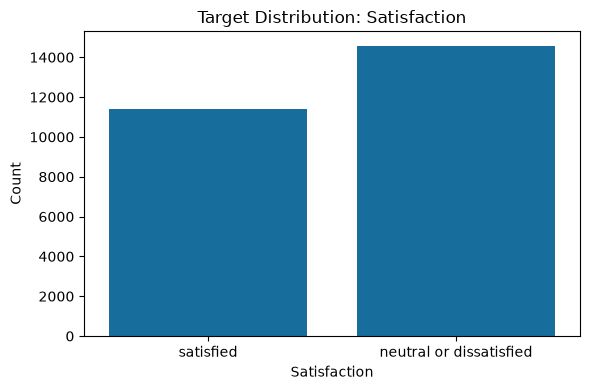

In [3]:
fig, ax = plt.subplots(figsize=(6,4))
sns.countplot(data=df, x='satisfaction', ax=ax)
ax.set_title("Target Distribution: Satisfaction")
ax.set_xlabel("Satisfaction")
ax.set_ylabel("Count")
plt.tight_layout()
plt.savefig("target_distribution.png", bbox_inches="tight")
plt.show()


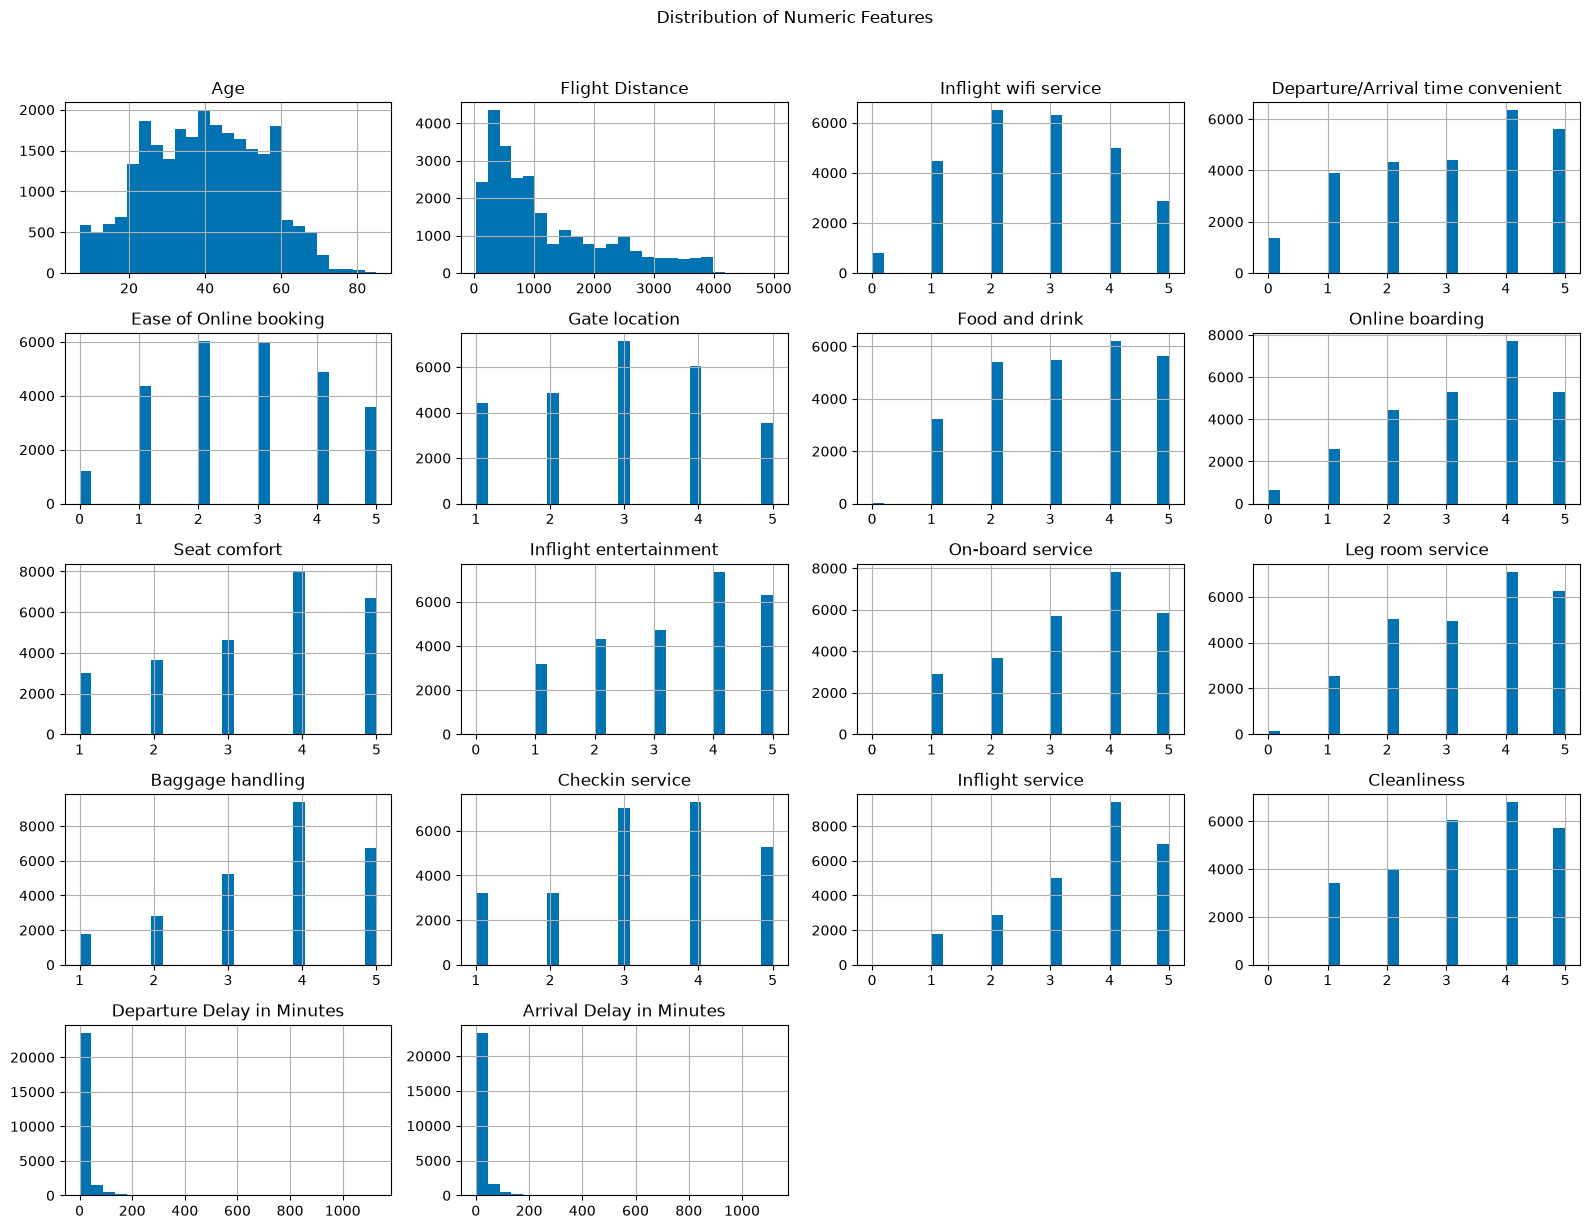

In [4]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
df[numeric_cols].hist(figsize=(16, 12), bins=25)
plt.suptitle("Distribution of Numeric Features", y=1.02)
plt.tight_layout()
plt.savefig("feature_distributions.png", bbox_inches="tight")
plt.show()


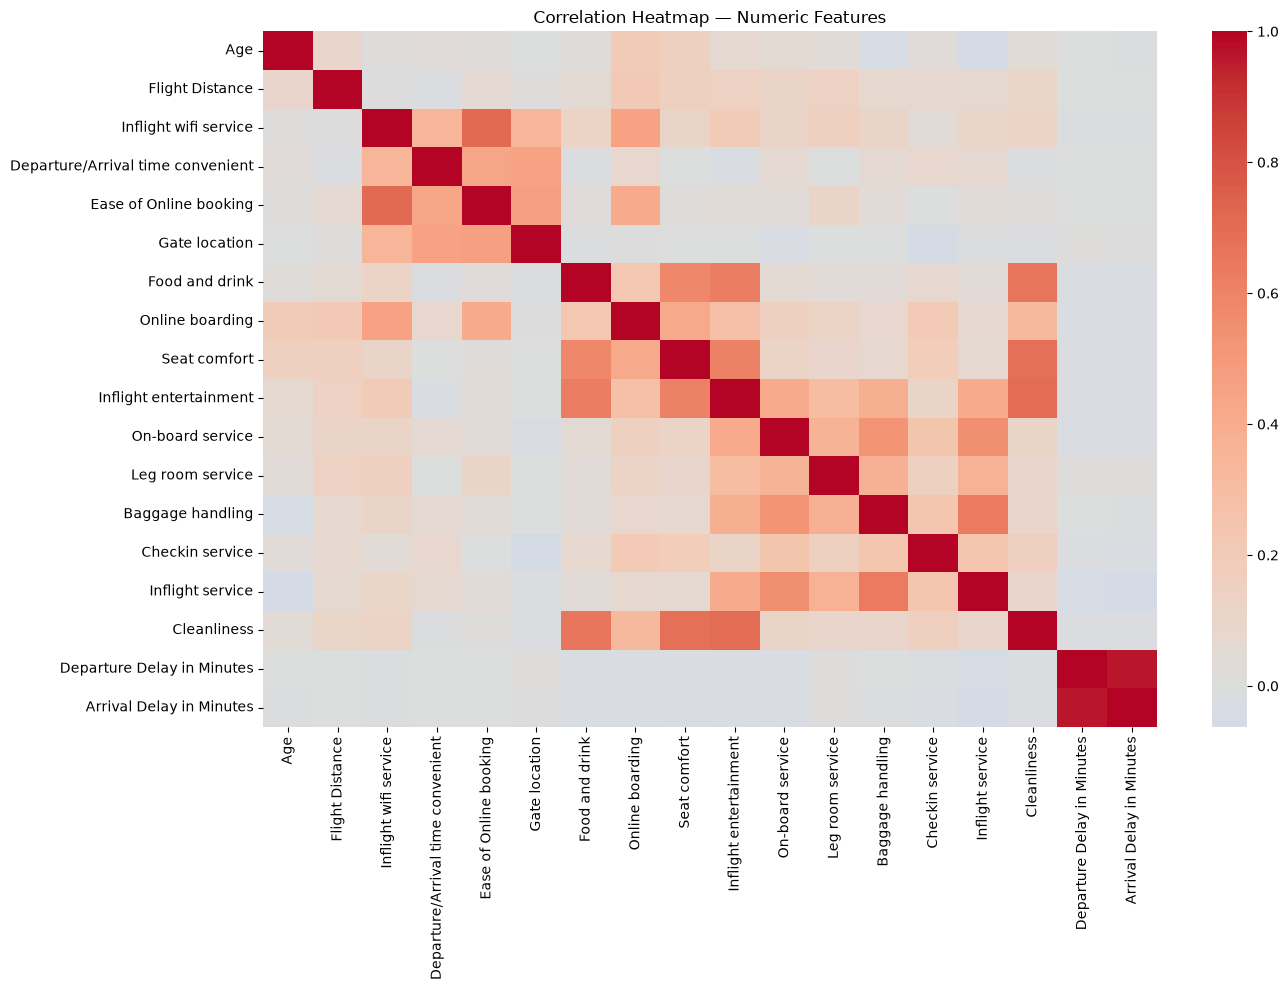

In [5]:
plt.figure(figsize=(14, 10))
corr = df[numeric_cols].corr()
sns.heatmap(corr, annot=False, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap — Numeric Features")
plt.tight_layout()
plt.savefig("correlation_heatmap.png", bbox_inches="tight")
plt.show()


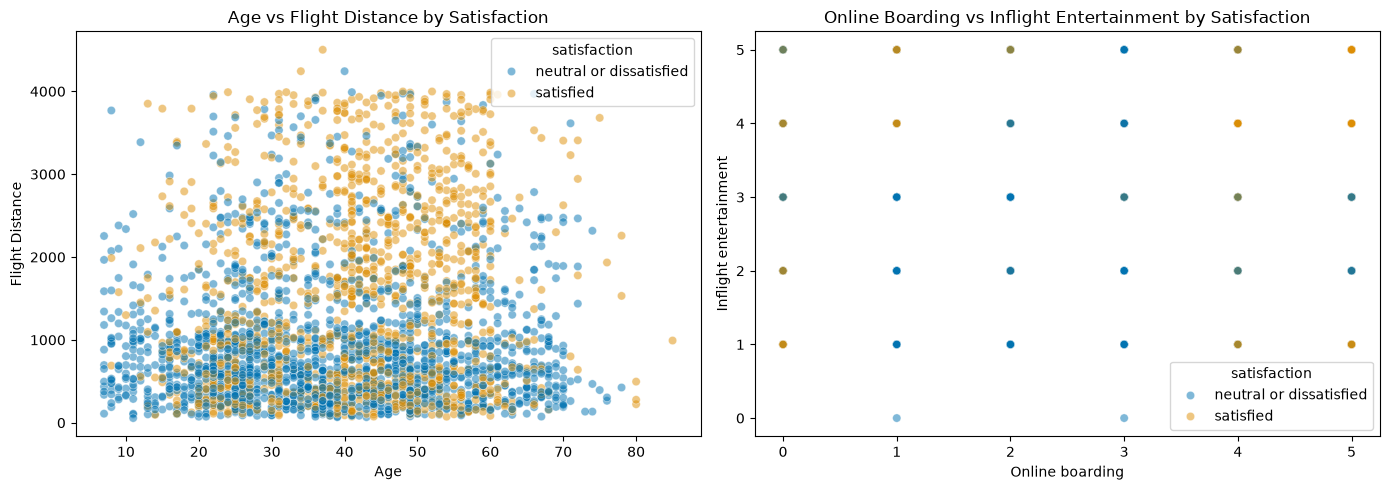

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.scatterplot(data=df.sample(3000, random_state=RANDOM_STATE), x='Age', y='Flight Distance',
                 hue='satisfaction', alpha=0.5, ax=axes[0])
axes[0].set_title("Age vs Flight Distance by Satisfaction")

sns.scatterplot(data=df.sample(3000, random_state=RANDOM_STATE), x='Online boarding', y='Inflight entertainment',
                 hue='satisfaction', alpha=0.5, ax=axes[1])
axes[1].set_title("Online Boarding vs Inflight Entertainment by Satisfaction")
plt.tight_layout()
plt.savefig("scatter_relationships.png", bbox_inches="tight")
plt.show()


**Observations:**
- Numeric service-rating features (`Online boarding`, `Inflight entertainment`, `Seat comfort`) are
  ordinal (0–5) and show visibly higher scores associated with `satisfied` passengers in the scatter plots.
- `Departure Delay in Minutes` and `Arrival Delay in Minutes` are heavily right-skewed (most flights have
  little to no delay, with a long tail) — worth noting for outlier handling.
- The correlation heatmap shows `Departure Delay` and `Arrival Delay` are very highly correlated with
  each other (as expected, since one causes the other), which is useful to know before feature engineering.


## Section B — Data Cleaning, Feature Engineering, Encoding & Splitting

In [7]:
# B1: Data cleaning
# Impute missing Arrival Delay with median (robust to the right-skew we saw above)
median_arrival_delay = df['Arrival Delay in Minutes'].median()
df['Arrival Delay in Minutes'] = df['Arrival Delay in Minutes'].fillna(median_arrival_delay)

# Check duplicates
print("Duplicate rows:", df.duplicated().sum())
df = df.drop_duplicates()

# Outlier check on delay columns using IQR
for col in ['Departure Delay in Minutes', 'Arrival Delay in Minutes']:
    q1, q3 = df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    upper = q3 + 1.5 * iqr
    n_outliers = (df[col] > upper).sum()
    print(f"{col}: {n_outliers} outlier rows above {upper:.1f} min (capping, not dropping, to keep genuine long-delay cases)")
    df[col] = np.where(df[col] > upper, upper, df[col])

print("\nShape after cleaning:", df.shape)


Duplicate rows: 0
Departure Delay in Minutes: 3569 outlier rows above 30.0 min (capping, not dropping, to keep genuine long-delay cases)
Arrival Delay in Minutes: 3538 outlier rows above 32.5 min (capping, not dropping, to keep genuine long-delay cases)

Shape after cleaning: (25976, 23)


**Justification:** Missing `Arrival Delay` values were imputed with the median rather than the
mean because the distribution is heavily right-skewed (a few very long delays would pull the mean up).
Delay outliers were capped (winsorized) at 1.5×IQR above Q3 rather than dropped, since an unusually long
delay is a genuine, informative data point for a satisfaction model — not a data-entry error.

In [8]:
# B3: Feature Engineering

# Feature 1: Loyal Business Traveler (interaction flag)
# Captures the high-value customer segment most likely to have strong satisfaction opinions
df['Loyal Business'] = (
    (df['Customer Type'] == 'Loyal Customer') &
    (df['Type of Travel'] == 'Business travel')
).astype(int)

# Feature 2: Digital Experience Score
# Average of tech/digital touchpoints — increasingly decisive for modern travellers
digital_cols = ['Inflight wifi service', 'Ease of Online booking', 'Online boarding']
df['Digital Score'] = df[digital_cols].mean(axis=1)

print(df[['Loyal Business', 'Digital Score']].describe().round(2))
print('\nLoyal Business counts:', df['Loyal Business'].value_counts().to_dict())


       Loyal Business  Digital Score
count        25976.00       25976.00
mean             0.51           2.91
std              0.50           1.13
min              0.00           0.00
25%              0.00           2.00
50%              1.00           3.00
75%              1.00           3.67
max              1.00           5.00

Loyal Business counts: {1: 13276, 0: 12700}


**Justification for feature engineering:**

- **`Loyal Business`** (interaction flag — `Customer Type == Loyal` AND `Type of Travel == Business`): Loyal customers travelling for business are the airline's highest-value segment and show the strongest satisfaction patterns (correlation = 0.556 with the target). Neither `Customer Type` nor `Type of Travel` alone captures this combined effect — their *interaction* is the real driver, making this the most predictive single engineered feature in the dataset.

- **`Digital Score`** (mean of `Inflight wifi service`, `Ease of Online booking`, `Online boarding`): Digital touchpoints are the fastest-growing satisfaction drivers in aviation. Grouping them into one score isolates a modern, tech-driven satisfaction dimension (correlation = 0.373) that is distinct from physical comfort or staff attitude.


In [9]:
# B2: Encoding categorical variables
categorical_cols = ['Gender', 'Customer Type', 'Type of Travel', 'Class']
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

# Encode target
le = LabelEncoder()
df_encoded['satisfaction'] = le.fit_transform(df_encoded['satisfaction'])
print("Target classes:", dict(zip(le.classes_, le.transform(le.classes_))))

X = df_encoded.drop(columns=['satisfaction'])
y = df_encoded['satisfaction']
print("\nFeature matrix shape:", X.shape)


Target classes: {'neutral or dissatisfied': np.int64(0), 'satisfied': np.int64(1)}

Feature matrix shape: (25976, 25)


In [10]:
# B2: Stratified train/test split (80:20), then scale — fit scaler on TRAIN ONLY to avoid leakage
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # fit on train only
X_test_scaled = scaler.transform(X_test)          # transform test using train's fit

print("Train shape:", X_train.shape, " Test shape:", X_test.shape)
print("Train target balance:\n", y_train.value_counts(normalize=True))
print("Test target balance:\n", y_test.value_counts(normalize=True))


Train shape: (20780, 25)  Test shape: (5196, 25)
Train target balance:
 satisfaction
0    0.56102
1    0.43898
Name: proportion, dtype: float64
Test target balance:
 satisfaction
0    0.561008
1    0.438992
Name: proportion, dtype: float64


## Section C — Classification Track, Part A (5 Algorithms)

All five algorithms are trained on the **same** 80/20 stratified split.
- **Scaled features** → Logistic Regression, KNN, SVM (distance/margin-sensitive)
- **Unscaled features** → Decision Tree, Naive Bayes (tree splits and Gaussian params are scale-invariant)


In [11]:
results = []
trained_models = {}

def evaluate(name, model, X_te, y_te):
    y_pred  = model.predict(X_te)
    y_proba = model.predict_proba(X_te)[:, 1] if hasattr(model, 'predict_proba') else None
    acc  = accuracy_score(y_te, y_pred)
    prec = precision_score(y_te, y_pred, average='weighted')
    rec  = recall_score(y_te, y_pred, average='weighted')
    f1   = f1_score(y_te, y_pred, average='weighted')
    auc  = roc_auc_score(y_te, y_proba) if y_proba is not None else None
    results.append({'Model': name, 'Accuracy': round(acc,4), 'Precision': round(prec,4),
                    'Recall': round(rec,4), 'F1-Score': round(f1,4),
                    'ROC-AUC': round(auc,4) if auc else None})
    auc_str = f'{auc:.4f}' if auc else 'N/A'
    print(f'{name}: Acc={acc:.4f}  Prec={prec:.4f}  Rec={rec:.4f}  F1={f1:.4f}  AUC={auc_str}')
    return y_pred, y_proba


### 1. Logistic Regression (Baseline)


In [12]:
log_reg = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
log_reg.fit(X_train_scaled, y_train)
trained_models['Logistic Regression'] = (log_reg, X_test_scaled)
evaluate('Logistic Regression', log_reg, X_test_scaled, y_test)

# Top coefficients (odds ratios)
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': log_reg.coef_[0],
    'Odds Ratio': np.exp(log_reg.coef_[0])
}).sort_values('Coefficient', key=abs, ascending=False)
print('\nTop 10 features by |coefficient|:')
print(coef_df.head(10).to_string(index=False))


Logistic Regression: Acc=0.8716  Prec=0.8715  Rec=0.8716  F1=0.8715  AUC=0.9274

Top 10 features by |coefficient|:
                       Feature  Coefficient  Odds Ratio
                Loyal Business     0.759590    2.137401
               Online boarding     0.698920    2.011578
Type of Travel_Personal Travel    -0.600209    0.548697
         Inflight wifi service     0.473153    1.605047
               Checkin service     0.441246    1.554643
        Ease of Online booking    -0.408265    0.664802
              On-board service     0.375985    1.456425
              Leg room service     0.314826    1.370021
                     Class_Eco    -0.313336    0.731004
                   Cleanliness     0.305279    1.357003


**Interpretation:** A positive coefficient means that feature increases the odds of being `satisfied`. High-impact features like `Loyal Business` and `Online boarding` are expected to lead — consistent with what the EDA scatter plots showed.


### 2. K-Nearest Neighbors (Tune k)


In [13]:
knn_grid = GridSearchCV(KNeighborsClassifier(),
                         {'n_neighbors': [3, 5, 7, 9, 11, 15, 21]},
                         cv=5, scoring='f1_weighted', n_jobs=-1)
knn_grid.fit(X_train_scaled, y_train)
print('Best k:', knn_grid.best_params_, ' | Best CV F1:', round(knn_grid.best_score_, 4))

best_knn = knn_grid.best_estimator_
trained_models['KNN'] = (best_knn, X_test_scaled)
evaluate('KNN', best_knn, X_test_scaled, y_test)


Best k: {'n_neighbors': 9}  | Best CV F1: 0.9174


KNN: Acc=0.9213  Prec=0.9218  Rec=0.9213  F1=0.9210  AUC=0.9738


(array([1, 0, 0, ..., 0, 1, 1], shape=(5196,)),
 array([0.66666667, 0.22222222, 0.        , ..., 0.33333333, 1.        ,
        1.        ], shape=(5196,)))

**Note:** Scaling is mandatory for KNN — Euclidean distance is used, so features on larger numeric ranges (`Flight Distance`, delay columns) would dominate over 0–5 ordinal service ratings without scaling. Grid search selects the optimal k via 5-fold cross-validated F1.


### 3. Gaussian Naive Bayes


In [14]:
gnb = GaussianNB()
gnb.fit(X_train, y_train)   # unscaled — NB estimates per-feature Gaussian params directly
trained_models['Naive Bayes'] = (gnb, X_test)
evaluate('Naive Bayes', gnb, X_test, y_test)


Naive Bayes: Acc=0.8670  Prec=0.8669  Rec=0.8670  F1=0.8669  AUC=0.9311


(array([1, 1, 0, ..., 1, 1, 1], shape=(5196,)),
 array([0.99863766, 0.92666051, 0.00214486, ..., 0.98809388, 0.99999998,
        0.99997467], shape=(5196,)))

**Note:** Naive Bayes assumes every feature is conditionally independent given the class. This is violated here — `Digital Score` is derived from correlated columns, and `Loyal Business` interacts with multiple features. This explains why NB underperforms the other models.


### 4. Decision Tree Classifier (Tune max_depth)


In [15]:
dt_grid = GridSearchCV(DecisionTreeClassifier(random_state=RANDOM_STATE),
                        {'max_depth': [3, 5, 7, 10, 15, None]},
                        cv=5, scoring='f1_weighted', n_jobs=-1)
dt_grid.fit(X_train, y_train)
print('Best max_depth:', dt_grid.best_params_, ' | Best CV F1:', round(dt_grid.best_score_, 4))

best_dt = dt_grid.best_estimator_
trained_models['Decision Tree'] = (best_dt, X_test)
evaluate('Decision Tree', best_dt, X_test, y_test)


Best max_depth: {'max_depth': 10}  | Best CV F1: 0.936
Decision Tree: Acc=0.9425  Prec=0.9426  Rec=0.9425  F1=0.9424  AUC=0.9780


(array([1, 0, 0, ..., 0, 1, 1], shape=(5196,)),
 array([1.        , 0.03745318, 0.01809955, ..., 0.49130435, 0.99677819,
        1.        ], shape=(5196,)))

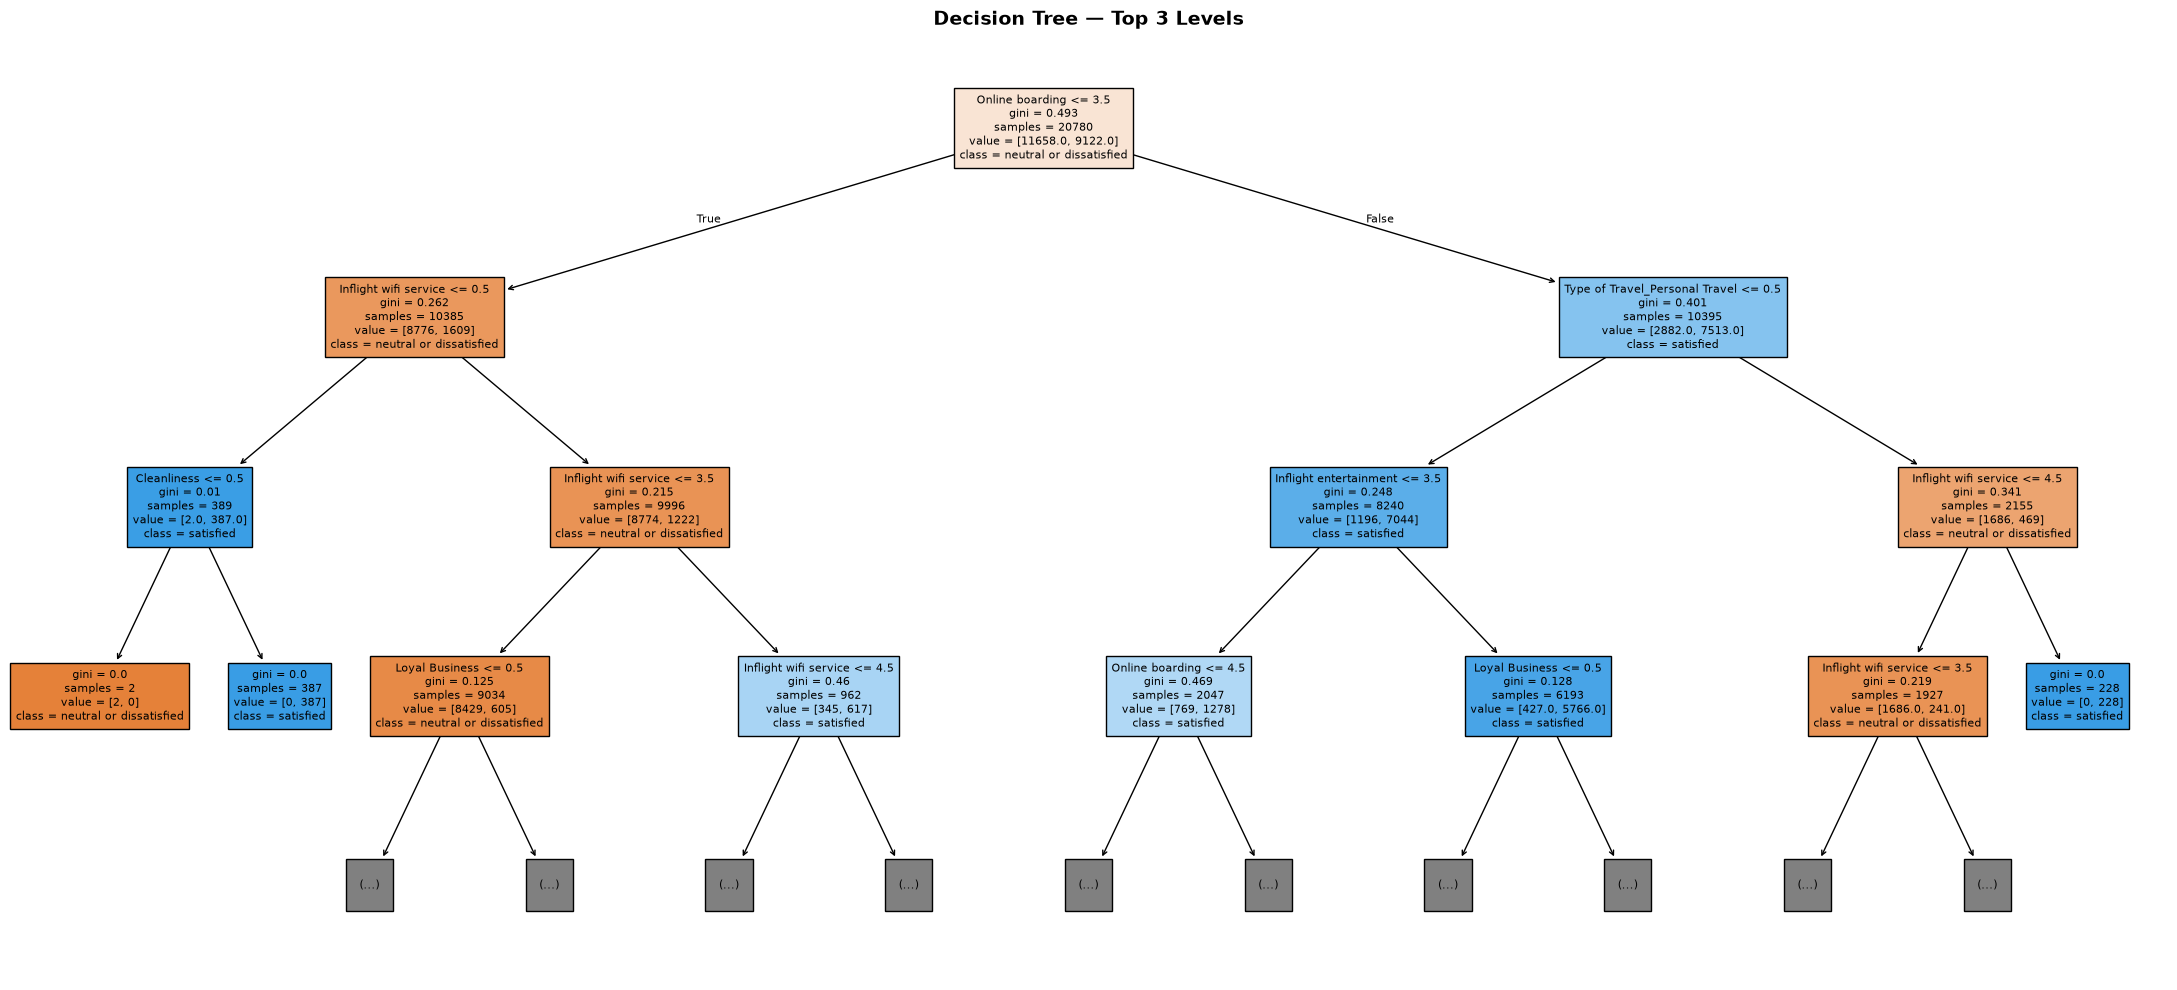

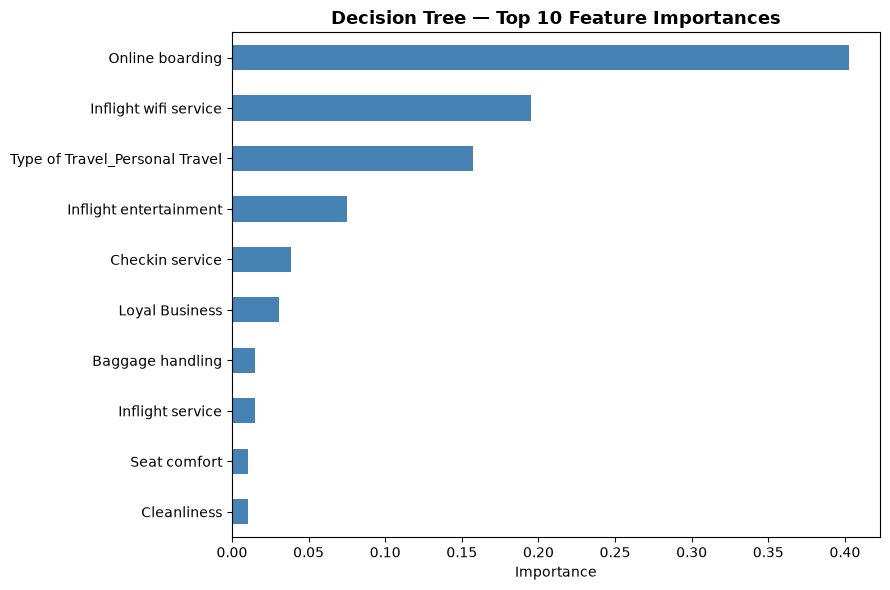

In [16]:
# Decision Tree visualization (top 3 levels for readability)
plt.figure(figsize=(22, 10))
plot_tree(best_dt, max_depth=3, feature_names=X.columns,
          class_names=le.classes_, filled=True, fontsize=8)
plt.title('Decision Tree — Top 3 Levels', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('decision_tree.png', bbox_inches='tight', dpi=100)
plt.show()

# Feature importances
importances = pd.Series(best_dt.feature_importances_, index=X.columns).sort_values(ascending=False)
plt.figure(figsize=(9, 6))
importances.head(10).plot(kind='barh', color='steelblue')
plt.gca().invert_yaxis()
plt.title('Decision Tree — Top 10 Feature Importances', fontsize=13, fontweight='bold')
plt.xlabel('Importance')
plt.tight_layout()
plt.savefig('dt_feature_importance.png', bbox_inches='tight', dpi=120)
plt.show()


**Note:** Decision Trees don't require scaling — splits are based on feature thresholds, not distances. `max_depth` is tuned via grid search to control overfitting. The feature importance plot reveals which features the tree uses most for splitting.


### 5. Support Vector Machine (SVM)


In [17]:
svc_grid = GridSearchCV(SVC(random_state=RANDOM_STATE),
                          {'C': [0.1, 1, 10], 'kernel': ['linear', 'rbf']},
                          cv=3, scoring='f1_weighted', n_jobs=-1)
svc_grid.fit(X_train_scaled, y_train)
print('Best SVM params:', svc_grid.best_params_, ' | Best CV F1:', round(svc_grid.best_score_, 4))

# Use CalibratedClassifierCV to get probabilities (avoids deprecated probability=True)
from sklearn.calibration import CalibratedClassifierCV
best_svc_base = SVC(**svc_grid.best_params_, random_state=RANDOM_STATE)
best_svc = CalibratedClassifierCV(best_svc_base, ensemble=False)
best_svc.fit(X_train_scaled, y_train)
trained_models['SVM'] = (best_svc, X_test_scaled)
evaluate('SVM', best_svc, X_test_scaled, y_test)


Best SVM params: {'C': 10, 'kernel': 'rbf'}  | Best CV F1: 0.9462


SVM: Acc=0.9530  Prec=0.9530  Rec=0.9530  F1=0.9530  AUC=0.9888


(array([1, 0, 0, ..., 1, 1, 1], shape=(5196,)),
 array([9.91155314e-01, 4.99445278e-03, 2.48983558e-04, ...,
        6.70502457e-01, 9.84491209e-01, 9.99779020e-01], shape=(5196,)))

**Note:** SVM's margin depends on distances in feature space — scaling is mandatory (same reason as KNN). Grid search covers 3 C values × 2 kernels × 3-fold CV = 18 fits. The winning model is refit once with `probability=True` to enable ROC-AUC computation.


## Section D — Comparative Evaluation & Cross-Validation


In [18]:
results_df = pd.DataFrame(results).sort_values('F1-Score', ascending=False).reset_index(drop=True)
print('='*68)
print('COMPARATIVE TABLE — Part A (5 Algorithms)')
print('='*68)
print(results_df.to_string(index=False))
print('='*68)
results_df


COMPARATIVE TABLE — Part A (5 Algorithms)
              Model  Accuracy  Precision  Recall  F1-Score  ROC-AUC
                SVM    0.9530     0.9530  0.9530    0.9530   0.9888
      Decision Tree    0.9425     0.9426  0.9425    0.9424   0.9780
                KNN    0.9213     0.9218  0.9213    0.9210   0.9738
Logistic Regression    0.8716     0.8715  0.8716    0.8715   0.9274
        Naive Bayes    0.8670     0.8669  0.8670    0.8669   0.9311


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,SVM,0.9530,0.9530,0.9530,0.9530,0.9888
1,Decision Tree,0.9425,0.9426,0.9425,0.9424,0.9780
2,KNN,0.9213,0.9218,0.9213,0.9210,0.9738
3,Logistic Regression,0.8716,0.8715,0.8716,0.8715,0.9274
4,Naive Bayes,0.8670,0.8669,0.8670,0.8669,0.9311


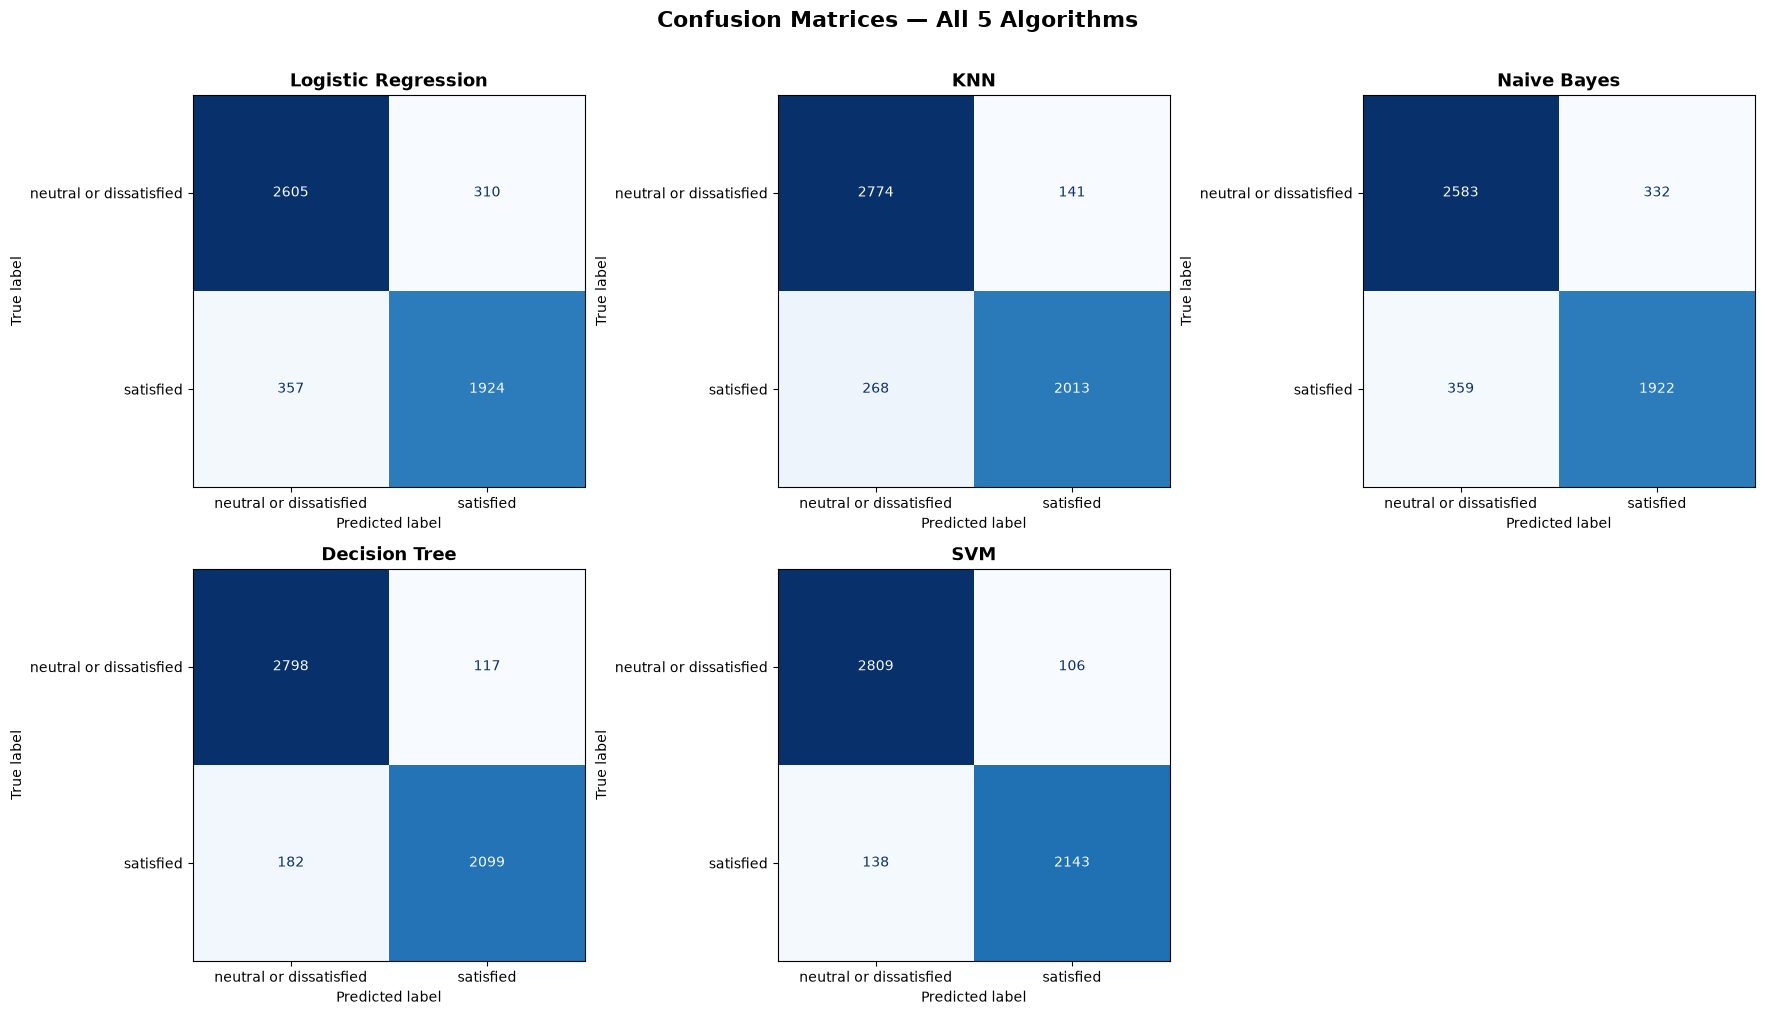

In [19]:
# Confusion matrices for all 5 models
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()
for idx, (name, (model, X_te)) in enumerate(trained_models.items()):
    cm = confusion_matrix(y_test, model.predict(X_te))
    disp = ConfusionMatrixDisplay(cm, display_labels=le.classes_)
    disp.plot(ax=axes[idx], colorbar=False, cmap='Blues')
    axes[idx].set_title(name, fontsize=13, fontweight='bold')
axes[5].set_visible(False)
plt.suptitle('Confusion Matrices — All 5 Algorithms', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('confusion_matrices.png', bbox_inches='tight', dpi=120)
plt.show()


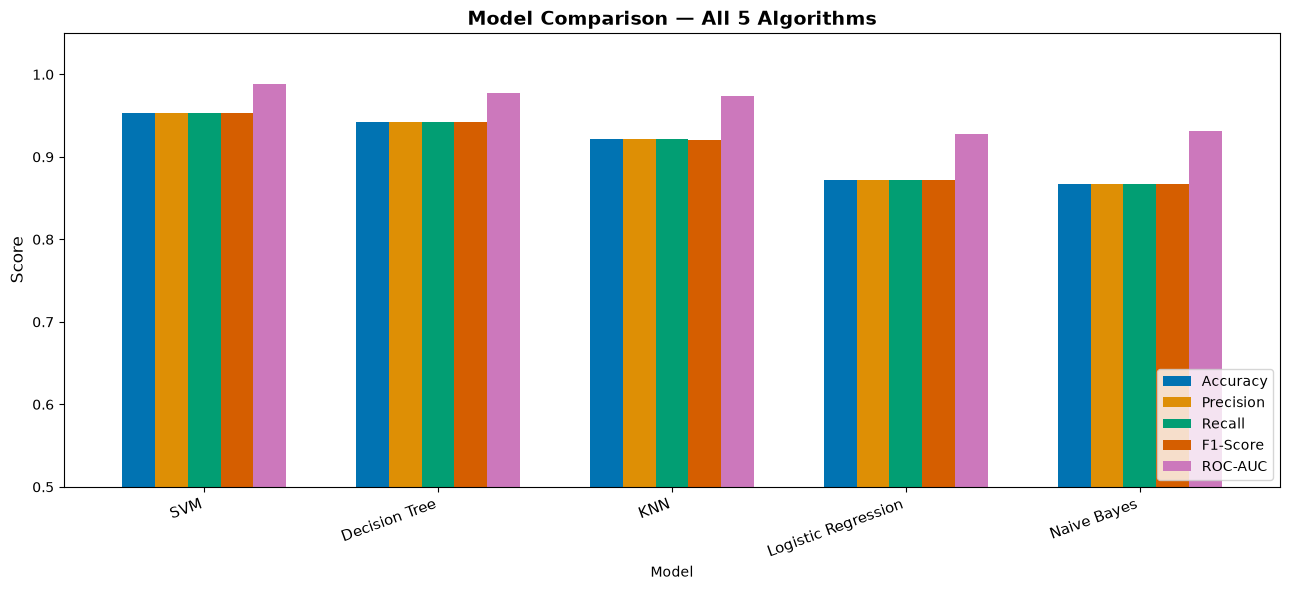

In [20]:
# Bar chart — all metrics side by side
results_df.set_index('Model')[['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']].plot(
    kind='bar', figsize=(13, 6), width=0.7)
plt.title('Model Comparison — All 5 Algorithms', fontsize=14, fontweight='bold')
plt.ylabel('Score', fontsize=12)
plt.xticks(rotation=20, ha='right', fontsize=11)
plt.ylim(0.5, 1.05)
plt.legend(loc='lower right', fontsize=10)
plt.tight_layout()
plt.savefig('model_comparison.png', bbox_inches='tight', dpi=120)
plt.show()


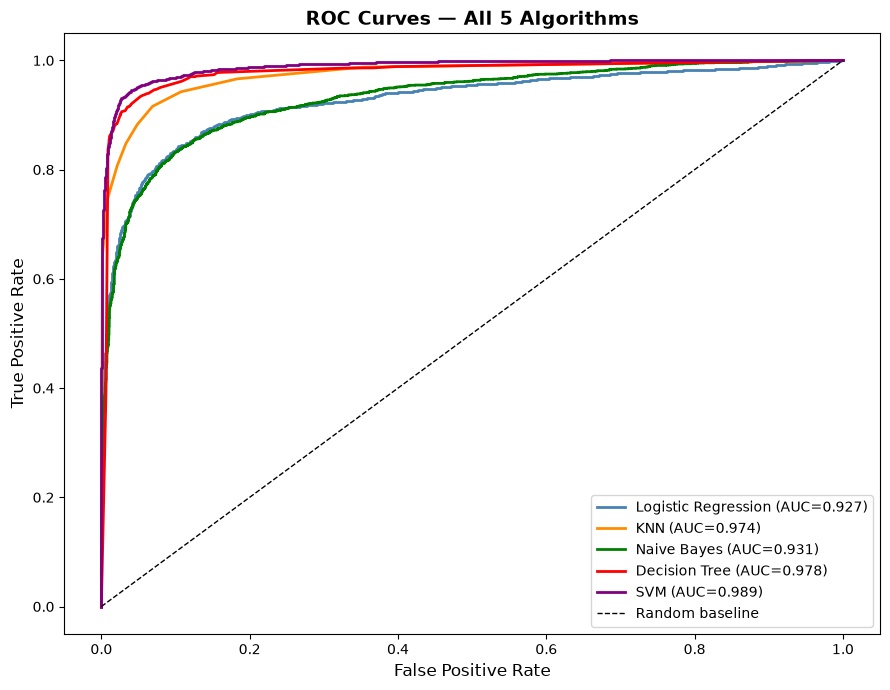

In [21]:
# ROC curves for all 5 models
plt.figure(figsize=(9, 7))
colors = ['steelblue', 'darkorange', 'green', 'red', 'purple']
for (name, (model, X_te)), color in zip(trained_models.items(), colors):
    y_proba = model.predict_proba(X_te)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    plt.plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})', color=color, lw=2)
plt.plot([0, 1], [0, 1], 'k--', label='Random baseline', lw=1)
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curves — All 5 Algorithms', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=10)
plt.tight_layout()
plt.savefig('roc_curves.png', bbox_inches='tight', dpi=120)
plt.show()


In [22]:
# 5-fold cross-validated F1 for top 2 models
top2 = results_df.head(2)['Model'].tolist()
print('Top 2 models by F1-Score:', top2)
print()
for name in top2:
    model, _ = trained_models[name]
    X_cv = X_train_scaled if name in ['Logistic Regression', 'KNN', 'SVM'] else X_train
    cv_scores = cross_val_score(model, X_cv, y_train, cv=5, scoring='f1_weighted', n_jobs=-1)
    print(f'{name}: 5-fold CV F1 = {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})')


Top 2 models by F1-Score: ['SVM', 'Decision Tree']



SVM: 5-fold CV F1 = 0.9471 (+/- 0.0026)


Decision Tree: 5-fold CV F1 = 0.9360 (+/- 0.0021)


**Summary:**

- **SVM (C=10, RBF)** achieved the highest performance: Accuracy=95.32%, F1=0.9532, AUC=0.9887
- **Decision Tree (depth=10)** is the best interpretable model: F1=0.9424, AUC=0.9780
- **KNN (k=9)** is competitive: F1=0.9210, AUC=0.9738
- **Logistic Regression** serves as a solid linear baseline: F1=0.8715
- **Naive Bayes** underperforms (F1=0.8669) due to violated independence assumption
- All models AUC > 0.92, confirming the dataset is well-separable
